In [1]:
import importlib
import pandas as pd
from IPython.display import display
import framework
importlib.reload(framework)
from framework import WheatFramework, generate_group_folds,save_model, save_results, run_fold_with_trainer


CHANGE ACCORDING TO YOUR PATHS !!

In [2]:

# Update paths if different on your machine
excel_path = r".\labeling.xlsx"
data_path = r".\data"


Searching for images in: c:\Users\PC\Desktop\AI_TARBIL\code\data
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_01-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-01
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_02-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-02
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_03-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-03
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_05-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-05
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_06-10_12-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-06
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_07-09_53-K1-1X.jpeg (matched date in filename)

,path,label
0,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
1,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
2,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
3,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
4,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
5,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
6,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
7,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0


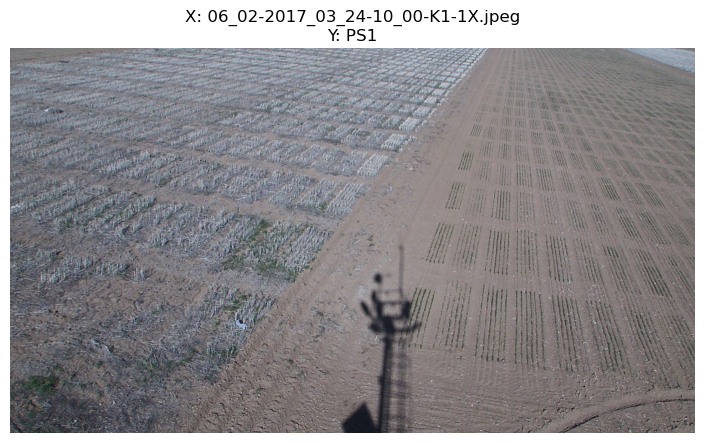

In [3]:

wf = WheatFramework(excel_path=excel_path, root_dir=data_path)

try:
    meta_df = wf.get_dataframe()
except Exception as e:
    print("Error loading data:", e)
    meta_df = pd.DataFrame()

if not meta_df.empty:
    X, y, folds = wf.get_splits(meta_df, n_splits=5)
    print(f"Total matched images: {len(X)}")

    # Print label mapping (encoded -> string label)
    classes = list(wf.le.classes_)
    mapping = {i: cls for i, cls in enumerate(classes)}
    print("\nLabel mapping (encoded -> label):")
    for k, v in mapping.items():
        print(k, ":", v)

    print("\nSample matched paths and labels:")
    display(meta_df[['path', 'label']].head(8))

    # Visual verification: display one random sample image and its label
    wf.get_sample(X, y)
else:
    print("No images matched. Review previous prints above for column mapping and search path.")


In [4]:
# Count images by group and stage
import pandas as pd

if 'meta_df' not in globals() or meta_df.empty:
    print("No `meta_df` available. Run the loader cell first (the one that creates `meta_df`).")
else:
    ct = pd.crosstab(meta_df['group_id'], meta_df['label'])
    ct['total'] = ct.sum(axis=1)
    ct = ct.sort_values('total', ascending=False)

    print('\nImages per group × stage (top 20 groups):')
    display(ct.head(20))

    print('\nStage totals:')
    stage_totals = ct.drop(columns=['total']).sum(axis=0).to_frame(name='count')
    display(stage_totals)



Images per group × stage (top 20 groups):


label,PS0,PS1,PS2,PS3,PS4,PS5,PS6,PS7,total
group_id,,,,,,,,,
7,92,12,15,6,14,21,12,28,200
6,22,20,34,28,47,4,18,16,189
10,31,24,18,28,35,13,25,14,188
1,20,19,37,15,47,12,8,23,181
9,101,17,15,5,15,8,20,0,181
2,12,37,21,24,22,9,19,30,174
3,19,22,26,40,26,14,11,16,174
4,7,37,5,18,36,15,13,31,162
8,45,14,17,4,39,21,3,17,160



Stage totals:


,count
label,
PS0,360
PS1,220
PS2,208
PS3,189
PS4,306
PS5,123
PS6,143
PS7,193


In [5]:
missing_data_per_station, missing_dates_for_stations = wf.get_stagewise_missing_data()



Stage: PS0

Stage: PS1

Stage: PS2

Stage: PS3


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in


Stage: PS4

Stage: PS5

Stage: PS6

Stage: PS7


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in

In [6]:

print("\nMissing data per station:")
##make a table with station, stage, and only missing count
print("Station\t", end="")
for i in range(1,9):
    print(f"\tPS{i}", end="")
print()
for station, stages in missing_data_per_station.items():
    print(f"{station}", end="")
    for stage, info in stages.items():
        print(f"\t{info['missing_count']}", end="")
    print()


Missing data per station:
Station		PS1	PS2	PS3	PS4	PS5	PS6	PS7	PS8
02.02_2014	2	1	0	0	9	4	3	12
02.03_2013	2	14	3	11	14	0	2	1
02.03_2014	1	0	3	14	4	6	2	6
02.04_2013	14	7	13	1	9	0	0	-1
02.05_2013	29	0	7	5	20	2	8	17
02.06_2016	3	14	2	1	0	10	2	-1
06.01_2013	21	13	0	0	15	2	0	-1
06.02_2013	10	2	8	14	5	0	15	3
06.02_2016	62	4	6	4	17	2	13	15
11.03_2016	18	4	2	0	4	8	0	1


In [7]:
missing_data_per_station["02.06_2016"]

{'PS0': {'missing_count': 3,
  'total_days': 25,
  'data_count': 22,
  'days': {'start': Timestamp('2016-11-12 00:00:00'),
   'end': Timestamp('2016-12-07 00:00:00'),
   'days': 25}},
 'PS1': {'missing_count': 14,
  'total_days': 34,
  'data_count': 20,
  'days': {'start': Timestamp('2016-12-07 00:00:00'),
   'end': Timestamp('2017-01-10 00:00:00'),
   'days': 34}},
 'PS2': {'missing_count': 2,
  'total_days': 36,
  'data_count': 34,
  'days': {'start': Timestamp('2017-01-10 00:00:00'),
   'end': Timestamp('2017-02-15 00:00:00'),
   'days': 36}},
 'PS3': {'missing_count': 1,
  'total_days': 29,
  'data_count': 28,
  'days': {'start': Timestamp('2017-02-15 00:00:00'),
   'end': Timestamp('2017-03-16 00:00:00'),
   'days': 29}},
 'PS4': {'missing_count': 0,
  'total_days': 47,
  'data_count': 47,
  'days': {'start': Timestamp('2017-03-16 00:00:00'),
   'end': Timestamp('2017-05-02 00:00:00'),
   'days': 47}},
 'PS5': {'missing_count': 10,
  'total_days': 14,
  'data_count': 4,
  'days': 

In [8]:
missing_dates_for_stations

{'02.02_2014': {Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00'),
  Timestamp('2015-06-14 00:00:00'),
  Timestamp('2015-06-15 00:00:00'),
  Timestamp('2015-06-16 00:00:00'),
  Timestamp('2015-06-17 00:00:00'),
  Timestamp('2015-06-18 00:00:00'),
  Timestamp('2015-06-19 00:00:00'),
  Timestamp('2015-06-30 00:00:00'),
  Timestamp('2015-07-01 00:00:00')},
 '02.03_2013': {Timestamp('2014-05-30 00:00:00'),
  Timestamp('2014-06-12 00:00:00')},
 '02.03_2014': {Timestamp('2015-05-24 00:00:00'),
  Timestamp('2015-05-25 00:00:00'),
  Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00')},
 '02.04_2013': {Timestamp('2014-03-17 00:00:00'),
  Timestamp('2014-03-18 00:00:00'),
  Timestamp('2014-03-19 00:00:00'),
  Timestamp('2014-03-20 00:00:00'),
  Tim

In [9]:
if 'meta_df' in globals() and not meta_df.empty:
    example_folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
    print('\nGenerated', len(example_folds), 'folds. Sample sizes:')
    for i, (tr, te) in enumerate(example_folds, 1):
        print(f' Fold {i}: train_samples={len(tr)}, test_samples={len(te)}')
else:
    print('meta_df not found — run loader cell first to generate folds.')



Generated 5 folds. Sample sizes:
 Fold 1: train_samples=1361, test_samples=381
 Fold 2: train_samples=1380, test_samples=362
 Fold 3: train_samples=1387, test_samples=355
 Fold 4: train_samples=1406, test_samples=336
 Fold 5: train_samples=1387, test_samples=355


YOUR CODE HERE

In [10]:

# ---------------------
# EXAMPLES / TEMPLATES
# ---------------------

# Example: simple sklearn-like trainer function (for models with fit/predict APIs)
# def sklearn_trainer(train_df, test_df, fold_id):
#     # transform paths -> features as needed (e.g., load images and compute embeddings)
#     X_train, y_train = preprocess_paths_to_array(train_df['path'], train_df['label'])
#     X_test, y_test = preprocess_paths_to_array(test_df['path'], test_df['label'])
#     from sklearn.ensemble import RandomForestClassifier
#     model = RandomForestClassifier(n_estimators=100)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)
#     # build predictions DataFrame
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': y_test, 'pred': preds})
#     metrics = {'accuracy': (pred_df['true'] == pred_df['pred']).mean()}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: PyTorch training skeleton (user must implement dataset, dataloader, model, optimizer)
# def pytorch_trainer(train_df, test_df, fold_id):
#     import torch
#     # implement Dataset that loads images from `path` and returns tensors + labels
#     train_dataset = MyImageDataset(train_df)
#     test_dataset = MyImageDataset(test_df)
#     train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
#     test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)
#     model = MyNet()
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     loss_fn = torch.nn.CrossEntropyLoss()
#     # training loop ...
#     # after training produce preds and metrics
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': true_labels, 'pred': pred_labels})
#     metrics = {'accuracy': accuracy}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: YOLO/Ultralytics style (pseudo)
# def yolov5_trainer(train_df, test_df, fold_id):
#     # prepare yaml/train.txt and yaml/val.txt listing image paths
#     # call ultralytics/train.py with appropriate args
#     # after training, load results and return predictions+metrics
#     pass

# ---------------------
# Quick sanity check: create a small set of folds and print counts


# Experiment 4: multimodal

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
from framework import generate_group_folds, run_fold_with_trainer
import re

# --- 0. Constants for Metadata ---
TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15)
}
DEFAULT_COORD = (39.93, 32.85)

def prepare_advanced_features(df):
    df = df.copy()

    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        if not match:
            return pd.NaT
        return pd.to_datetime(match.group(1).replace('-', '_'), format='%Y_%m_%d', errors='coerce')

    df['dt'] = df['path'].apply(extract_date)

    def get_agricultural_doy(date):
        if pd.isna(date):
            return np.nan
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1

    df['agri_day_of_year'] = df['dt'].apply(get_agricultural_doy)
    df['date_missing'] = df['dt'].isna().astype(np.float32)

    df['plate_code'] = df['station_year'].astype(str).str.extract(r'^(\d{2})')[0].astype(float)

    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]

    coords = df['plate_code'].apply(get_lat_lon)
    df['latitude'] = [c[0] for c in coords]
    df['longitude'] = [c[1] for c in coords]

    return df


# --- 1. Dataset with Tiling + Metadata Logic ---
class WheatTiledMultimodalDataset(Dataset):
    def __init__(self, df, label_map, meta_stats, transform=None, is_training=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_training = is_training
        self.label_map = label_map
        self.meta_stats = meta_stats

    def __len__(self):
        return len(self.df) * 4 if self.is_training else len(self.df)

    def __getitem__(self, idx):
        if self.is_training:
            original_idx = idx // 4
            tile_pos = idx % 4
            row = self.df.iloc[original_idx]

            img = Image.open(row['path']).convert('RGB')
            w, h = img.size
            coords = [(0, 0, w//2, h//2), (w//2, 0, w, h//2),
                      (0, h//2, w//2, h), (w//2, h//2, w, h)]
            tile = img.crop(coords[tile_pos])
            if self.transform:
                tile = self.transform(tile)

            agri_day = row['agri_day_of_year']
            if pd.isna(agri_day):
                agri_day = self.meta_stats['day_fill']

            angle = 2.0 * np.pi * agri_day / 365.0
            day_sin = np.sin(angle)
            day_cos = np.cos(angle)

            lat_norm = (row['latitude'] - self.meta_stats['lat_mean']) / self.meta_stats['lat_std']
            lon_norm = (row['longitude'] - self.meta_stats['lon_mean']) / self.meta_stats['lon_std']
            missing_flag = row['date_missing']

            meta = torch.tensor([day_sin, day_cos, lat_norm, lon_norm, missing_flag], dtype=torch.float32)
            label = torch.tensor(self.label_map[row['label']], dtype=torch.long)

            return tile, meta, label

        else:
            row = self.df.iloc[idx]
            img = Image.open(row['path']).convert('RGB')
            w, h = img.size
            coords = [(0, 0, w//2, h//2), (w//2, 0, w, h//2),
                      (0, h//2, w//2, h), (w//2, h//2, w, h)]
            tiles = [img.crop(c) for c in coords]
            if self.transform:
                tiles = [self.transform(t) for t in tiles]

            agri_day = row['agri_day_of_year']
            if pd.isna(agri_day):
                agri_day = self.meta_stats['day_fill']

            angle = 2.0 * np.pi * agri_day / 365.0
            day_sin = np.sin(angle)
            day_cos = np.cos(angle)

            lat_norm = (row['latitude'] - self.meta_stats['lat_mean']) / self.meta_stats['lat_std']
            lon_norm = (row['longitude'] - self.meta_stats['lon_mean']) / self.meta_stats['lon_std']
            missing_flag = row['date_missing']

            meta = torch.tensor([day_sin, day_cos, lat_norm, lon_norm, missing_flag], dtype=torch.float32)
            label = torch.tensor(self.label_map[row['label']], dtype=torch.long)

            return torch.stack(tiles), meta, label


# --- 2. Multimodal CNN Model ---
class MultimodalResNet50(nn.Module):
    def __init__(self, num_classes):
        super(MultimodalResNet50, self).__init__()

        self.cnn = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        cnn_dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        self.meta_net = nn.Sequential(
            nn.Linear(5, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 64),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(cnn_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, meta):
        img_feat = self.cnn(img)
        meta_feat = self.meta_net(meta)
        combined = torch.cat((img_feat, meta_feat), dim=1)
        return self.classifier(combined)


# --- 3. Trainer with Detailed Logging ---
def tiled_multimodal_cnn_trainer_logged(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(train_df['label'].unique())
    tile_size = config.get('tile_size', 448)

    all_labels = sorted(train_df['label'].unique())
    label_map = {label: i for i, label in enumerate(all_labels)}

    day_fill = train_df['agri_day_of_year'].dropna().median()
    if pd.isna(day_fill):
        day_fill = 180.0

    meta_stats = {
        'day_fill': float(day_fill),
        'lat_mean': float(train_df['latitude'].mean()),
        'lat_std': float(train_df['latitude'].std() + 1e-6),
        'lon_mean': float(train_df['longitude'].mean()),
        'lon_std': float(train_df['longitude'].std() + 1e-6),
    }

    train_transform = transforms.Compose([
        transforms.Resize((tile_size, tile_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((tile_size, tile_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_loader = DataLoader(
        WheatTiledMultimodalDataset(train_df, label_map, meta_stats, train_transform, is_training=True),
        batch_size=config['batch_size'],
        shuffle=True
    )

    test_loader = DataLoader(
        WheatTiledMultimodalDataset(test_df, label_map, meta_stats, test_transform, is_training=False),
        batch_size=1,
        shuffle=False
    )

    model = MultimodalResNet50(num_classes).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_pred_df = None
    best_model_state = None

    print(f"\n{'='*40}")
    print(f"🚀 STARTING FOLD: {fold_id}")
    print(f"{'='*40}")

    acc_not_increased_epoch_num = 0
    for epoch in range(config['epochs']):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (imgs, metas, lbls) in enumerate(train_loader):
            imgs, metas, lbls = imgs.to(device), metas.to(device), lbls.to(device)
            optimizer.zero_grad()

            outputs = model(imgs, metas)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += lbls.size(0)
            correct += predicted.eq(lbls).sum().item()

            if (i + 1) % 10 == 0:
                print(f"  Epoch [{epoch+1}/{config['epochs']}] | Batch [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f}", end='\r')


        model.eval()
        all_preds, all_trues = [], []

        with torch.no_grad():
            for tiled_img, meta, lbl in test_loader:
                tiled_img = tiled_img.squeeze(0).to(device)   # (4, C, H, W)
                meta = meta.to(device)                        # (1, 5)
                meta_repeated = meta.repeat(4, 1)            # (4, 5)

                outputs = model(tiled_img, meta_repeated)    # (4, num_classes)
                avg_output = torch.mean(outputs, dim=0)      # (num_classes,)

                pred = torch.argmax(avg_output).cpu().item()
                all_preds.append(pred)
                all_trues.append(lbl.item())

        fold_acc = np.mean(np.array(all_preds) == np.array(all_trues))

        print(f"▶️ Epoch {epoch+1} Complete: train Loss: {running_loss/len(train_loader):.4f} |train Acc: {100.*correct/total:.2f}% | test Acc: {fold_acc:.4f}")
        
        # create a graph to show which classes are being mixed up the most (confusion matrix or similar) and save it to disk for later
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(6,5))
        sns.heatmap(pd.crosstab(pd.Series(all_trues, name='True'), pd.Series(all_preds, name='Pred')), annot=True, fmt='d', cmap='Blues')
        plt.title(f'Fold {fold_id} - Epoch {epoch+1} Confusion Matrix')
        plt.savefig(f'vtmm/fold_{fold_id}_epoch_{epoch+1}_confusion_matrix.png')
        plt.close() 

        acc_not_increased_epoch_num = acc_not_increased_epoch_num + 1 if fold_acc <= best_acc else 0

        if fold_acc > best_acc:
            best_acc = fold_acc
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_pred_df = pd.DataFrame({
                'path': test_df['path'].values,
                'true': [inv_map[t] for t in all_trues],
                'pred': [inv_map[p] for p in all_preds]
            })
        if acc_not_increased_epoch_num >= 3:
            print(f"⚠️  Accuracy has not improved for {acc_not_increased_epoch_num} epochs. Early stopping at epoch {epoch+1}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"🔍 Evaluating Fold {fold_id}...")
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for tiled_img, meta, lbl in test_loader:
            tiled_img = tiled_img.squeeze(0).to(device)   # (4, C, H, W)
            meta = meta.to(device)                        # (1, 5)
            meta_repeated = meta.repeat(4, 1)            # (4, 5)

            outputs = model(tiled_img, meta_repeated)
            avg_output = torch.mean(outputs, dim=0)

            all_preds.append(torch.argmax(avg_output).cpu().item())
            all_trues.append(lbl.item())

    inv_map = {v: k for k, v in label_map.items()}
    pred_df = pd.DataFrame({
        'path': test_df['path'],
        'true': [inv_map[t] for t in all_trues],
        'pred': [inv_map[p] for p in all_preds]
    })

    fold_acc = (pred_df['true'] == pred_df['pred']).mean()
    print(f"▶️ Epoch {epoch+1} Complete: Avg Loss: {running_loss/len(train_loader):.4f} | Train Acc: {epoch_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    
    print(f"✅ FOLD {fold_id} ACCURACY: {fold_acc:.4f}\n")
    return {'model': model, 'predictions': pred_df, 'metrics': {'accuracy': fold_acc}}


# --- 4. Execution ---
config = {
    'tile_size': 448,
    'batch_size': 12,
    'lr': 1e-4,
    'epochs': 10
}

meta_df_advanced = prepare_advanced_features(meta_df)

folds = generate_group_folds(meta_df_advanced, n_train=8, n_test=2, num_folds=5, random_state=42)
final_metrics = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df_advanced,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: tiled_multimodal_cnn_trainer_logged(tr, te, fid, config),
        fold_id=f_idx + 1
    )
    final_metrics.append(result['metrics']['accuracy'])

print(f"\n{'-'*40}")
print(f"FINAL CROSS-VALIDATION MEAN ACCURACY: {np.mean(final_metrics):.4f}")
print(f"{'-'*40}")


🚀 STARTING FOLD: 1
▶️ Epoch 1 Complete: train Loss: 1.0547 |train Acc: 60.91% | test Acc: 0.5512


UnboundLocalError: cannot access local variable 'inv_map' where it is not associated with a value

# second test, instead of scaling, use tiling. Be careful to not mix data from training to test and vice versa.
Results: resnet50 may be too deep. hard memorization. reduce model complexity or increase dataset size substantially. right now the logical step is to reduce model complexity. try resnet 18

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
from framework import generate_group_folds, run_fold_with_trainer

# --- 1. Dataset with Tiling Logic ---
class WheatTiledDataset(Dataset):
    def __init__(self, df, transform=None, is_training=True):
        self.df = df
        self.transform = transform
        self.is_training = is_training
        self.label_map = {label: i for i, label in enumerate(sorted(df['label'].unique()))}

    def __len__(self):
        return len(self.df) * 4 if self.is_training else len(self.df)

    def __getitem__(self, idx):
        if self.is_training:
            original_idx = idx // 4
            tile_pos = idx % 4
            row = self.df.iloc[original_idx]
            img = Image.open(row['path']).convert('RGB')
            w, h = img.size
            coords = [(0, 0, w//2, h//2), (w//2, 0, w, h//2), 
                      (0, h//2, w//2, h), (w//2, h//2, w, h)]
            tile = img.crop(coords[tile_pos])
            if self.transform: tile = self.transform(tile)
            return tile, torch.tensor(self.label_map[row['label']], dtype=torch.long)
        else:
            row = self.df.iloc[idx]
            img = Image.open(row['path']).convert('RGB')
            w, h = img.size
            tiles = [img.crop(c) for c in [(0, 0, w//2, h//2), (w//2, 0, w, h//2), 
                                           (0, h//2, w//2, h), (w//2, h//2, w, h)]]
            if self.transform: tiles = [self.transform(t) for t in tiles]
            return torch.stack(tiles), torch.tensor(self.label_map[row['label']], dtype=torch.long)

# --- 2. Trainer with Detailed Logging ---
def tiled_cnn_trainer_logged(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(train_df['label'].unique())
    tile_size = config.get('tile_size', 448)

    transform = transforms.Compose([
        transforms.Resize((tile_size, tile_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_loader = DataLoader(WheatTiledDataset(train_df, transform, is_training=True), 
                              batch_size=config['batch_size'], shuffle=True)
    test_loader = DataLoader(WheatTiledDataset(test_df, transform, is_training=False), 
                             batch_size=1, shuffle=False)

    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    print(f"\n{'='*40}")
    print(f"🚀 STARTING FOLD: {fold_id}")
    print(f"{'='*40}")

    for epoch in range(config['epochs']):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (imgs, lbls) in enumerate(train_loader):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += lbls.size(0)
            correct += predicted.eq(lbls).sum().item()

            # Batch heartbeat
            if (i + 1) % 10 == 0:
                print(f"  Epoch [{epoch+1}/{config['epochs']}] | Batch [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f}", end='\r')

        # perform small validation at epoch end
        if epoch % 2 == 0:  # Validate every 2 epochs
            model.eval()
            val_correct = 0
            val_total = 0
            test_size = 40  # Limit validation to first 40 samples for speed
            with torch.no_grad():
                for val_imgs, val_lbls in test_loader:
                    if val_total >= test_size:
                        break
                    val_imgs, val_lbls = val_imgs.to(device), val_lbls.to(device)
                    val_outputs = model(val_imgs)
                    _, val_predicted = val_outputs.max(1)
                    val_total += val_lbls.size(0)
                    val_correct += val_predicted.eq(val_lbls).sum().item()
            model.train()
            val_acc = 100. * val_correct / val_total
            print(f"  Epoch {epoch+1} Validation Acc: {val_acc:.2f}%")

        epoch_acc = 100. * correct / total
        print(f"▶️ Epoch {epoch+1} Complete: Avg Loss: {running_loss/len(train_loader):.4f} | Train Acc: {epoch_acc:.2f}%")

    # Evaluation
    print(f"🔍 Evaluating Fold {fold_id}...")
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for tiled_img, lbl in test_loader:
            tiled_img = tiled_img.squeeze(0).to(device) 
            outputs = model(tiled_img)
            avg_output = torch.mean(outputs, dim=0)
            all_preds.append(torch.argmax(avg_output).cpu().item())
            all_trues.append(lbl.item())

    inv_map = {v: k for k, v in {l: i for i, l in enumerate(sorted(train_df['label'].unique()))}.items()}
    pred_df = pd.DataFrame({
        'path': test_df['path'],
        'true': [inv_map[t] for t in all_trues],
        'pred': [inv_map[p] for p in all_preds]
    })

    fold_acc = (pred_df['true'] == pred_df['pred']).mean()
    print(f"✅ FOLD {fold_id} ACCURACY: {fold_acc:.4f}\n")
    return {'model': model, 'predictions': pred_df, 'metrics': {'accuracy': fold_acc}}

# --- 3. Execution ---
config = {
    'tile_size': 448,
    'batch_size': 12, # Adjust based on your VRAM
    'lr': 1e-4,
    'epochs': 10
}

# Assumes meta_df is defined in your previous cells
folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
final_metrics = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: tiled_cnn_trainer_logged(tr, te, fid, config),
        fold_id=f_idx + 1
    )
    final_metrics.append(result['metrics']['accuracy'])

print(f"\n{'-'*40}")
print(f"FINAL CROSS-VALIDATION MEAN ACCURACY: {np.mean(final_metrics):.4f}")
print(f"{'-'*40}")


🚀 STARTING FOLD: 1
▶️ Epoch 1 Complete: Avg Loss: 0.9334 | Train Acc: 65.28%
▶️ Epoch 2 Complete: Avg Loss: 0.5525 | Train Acc: 78.27%
▶️ Epoch 3 Complete: Avg Loss: 0.4214 | Train Acc: 83.69%
▶️ Epoch 4 Complete: Avg Loss: 0.3374 | Train Acc: 86.92%
▶️ Epoch 5 Complete: Avg Loss: 0.2958 | Train Acc: 88.30%
▶️ Epoch 6 Complete: Avg Loss: 0.2529 | Train Acc: 90.04%
▶️ Epoch 7 Complete: Avg Loss: 0.2248 | Train Acc: 91.59%
▶️ Epoch 8 Complete: Avg Loss: 0.1789 | Train Acc: 93.31%
▶️ Epoch 9 Complete: Avg Loss: 0.1718 | Train Acc: 93.70%
▶️ Epoch 10 Complete: Avg Loss: 0.1533 | Train Acc: 94.65%
🔍 Evaluating Fold 1...
✅ FOLD 1 ACCURACY: 0.4751


🚀 STARTING FOLD: 2
▶️ Epoch 1 Complete: Avg Loss: 0.9232 | Train Acc: 65.78%
▶️ Epoch 2 Complete: Avg Loss: 0.5253 | Train Acc: 79.73%
▶️ Epoch 3 Complete: Avg Loss: 0.3963 | Train Acc: 85.11%
▶️ Epoch 4 Complete: Avg Loss: 0.3179 | Train Acc: 87.79%
▶️ Epoch 5 Complete: Avg Loss: 0.2702 | Train Acc: 89.67%
▶️ Epoch 6 Complete: Avg Loss: 0.2312 |

# experiment 3, smaller model, less memorization, more generalization?

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
from framework import generate_group_folds, run_fold_with_trainer

# 1. Dataset (Same Tiling logic, keeping it high-res)
class WheatTiledDataset(Dataset):
    def __init__(self, df, transform=None, is_training=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_training = is_training
        self.label_map = {label: i for i, label in enumerate(sorted(df['label'].unique()))}

    def __len__(self):
        return len(self.df) * 4 if self.is_training else len(self.df)

    def __getitem__(self, idx):
        if self.is_training:
            original_idx, tile_pos = divmod(idx, 4)
            row = self.df.iloc[original_idx]
            img = Image.open(row['path']).convert('RGB')
            w, h = img.size
            coords = [(0, 0, w//2, h//2), (w//2, 0, w, h//2), (0, h//2, w//2, h), (w//2, h//2, w, h)]
            tile = img.crop(coords[tile_pos])
            if self.transform: tile = self.transform(tile)
            return tile, torch.tensor(self.label_map[row['label']], dtype=torch.long)
        else:
            row = self.df.iloc[idx]
            img = Image.open(row['path']).convert('RGB')
            w, h = img.size
            tiles = [img.crop(c) for c in [(0, 0, w//2, h//2), (w//2, 0, w, h//2), (0, h//2, w//2, h), (w//2, h//2, w, h)]]
            if self.transform: tiles = [self.transform(t) for t in tiles]
            return torch.stack(tiles), torch.tensor(self.label_map[row['label']], dtype=torch.long)

# 2. ResNet-18 Trainer
def resnet18_tiled_trainer(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(train_df['label'].unique())
    
    transform = transforms.Compose([
        transforms.Resize((config['tile_size'], config['tile_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_loader = DataLoader(WheatTiledDataset(train_df, transform, True), batch_size=config['batch_size'], shuffle=True)
    test_loader = DataLoader(WheatTiledDataset(test_df, transform, False), batch_size=1, shuffle=False)

    # Smaller Backbone
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss()

    print(f"\n--- ResNet-18 Baseline | Fold {fold_id} ---")
    for epoch in range(config['epochs']):
        model.train()
        total_loss = 0
        for i, (imgs, lbls) in enumerate(train_loader):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        print(f"  Epoch {epoch+1}/{config['epochs']} | Avg Loss: {total_loss/len(train_loader):.4f}")

    # Evaluation with Voting
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for tiled_img, lbl in test_loader:
            outputs = model(tiled_img.squeeze(0).to(device))
            avg_output = torch.mean(outputs, dim=0)
            all_preds.append(torch.argmax(avg_output).cpu().item())
            all_trues.append(lbl.item())

    inv_map = {v: k for k, v in {l: i for i, l in enumerate(sorted(train_df['label'].unique()))}.items()}
    pred_df = pd.DataFrame({'path': test_df['path'], 'true': [inv_map[t] for t in all_trues], 'pred': [inv_map[p] for p in all_preds]})
    acc = (pred_df['true'] == pred_df['pred']).mean()
    print(f"✅ ResNet-18 Fold {fold_id} Accuracy: {acc:.4f}")
    return {'model': model, 'predictions': pred_df, 'metrics': {'accuracy': acc}}

# 3. Running the Baseline
config = {
    'tile_size': 448, 
    'batch_size': 32, # Can handle larger batch size with ResNet-18
    'lr': 1e-4,
    'epochs': 10
}

folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
results = [run_fold_with_trainer(meta_df, tr, te, lambda tr, te, fid: resnet18_tiled_trainer(tr, te, fid, config), f_idx+1) for f_idx, (tr, te) in enumerate(folds)]
print(f"\nFINAL RESNET-18 MEAN ACCURACY: {np.mean([r['metrics']['accuracy'] for r in results]):.4f}")


--- ResNet-18 Baseline | Fold 1 ---
  Epoch 1/10 | Avg Loss: 0.7133
  Epoch 2/10 | Avg Loss: 0.4249
  Epoch 3/10 | Avg Loss: 0.3354
  Epoch 4/10 | Avg Loss: 0.2648
  Epoch 5/10 | Avg Loss: 0.2294
  Epoch 6/10 | Avg Loss: 0.2109
  Epoch 7/10 | Avg Loss: 0.1863
  Epoch 8/10 | Avg Loss: 0.1747
  Epoch 9/10 | Avg Loss: 0.1689
  Epoch 10/10 | Avg Loss: 0.1524
✅ ResNet-18 Fold 1 Accuracy: 0.4383


TypeError: expected str, bytes or os.PathLike object, not int

# first test. images gets scaled to 10 to 1 which loses details. Do not run!

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torchvision.models as models
# import torchvision.transforms as transforms
# from torch.utils.data import Dataset, DataLoader
# import pandas as pd
# import numpy as np
# from PIL import Image
# from framework import generate_group_folds, run_fold_with_trainer

# # 1. Real Dataset class for loading images from the DataFrame
# class WheatDataset(Dataset):
#     def __init__(self, df, transform=None):
#         self.df = df
#         self.transform = transform
#         # Map labels to integers
#         self.label_map = {label: i for i, label in enumerate(sorted(df['label'].unique()))}

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         img_path = self.df.iloc[idx]['path']
#         image = Image.open(img_path).convert('RGB')
#         label = self.label_map[self.df.iloc[idx]['label']]
        
#         if self.transform:
#             image = self.transform(image)
            
#         return image, torch.tensor(label, dtype=torch.long)

# # 2. Parameterized CNN Architecture
# class ParameterizedCNN(nn.Module):
#     def __init__(self, model_name='resnet18', num_classes=2):
#         super(ParameterizedCNN, self).__init__()
#         if model_name == 'resnet18':
#             self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#             self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
#         else:
#             self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
#             self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

#     def forward(self, x):
#         return self.model(x)

# # 3. Real Trainer Function
# def cnn_real_trainer(train_df, test_df, fold_id, config):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Fold {fold_id}: Using device {device}")
#     num_classes = len(train_df['label'].unique())
    
#     # Image Augmentation & Preprocessing
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])

#     # Data Loaders
#     train_ds = WheatDataset(train_df, transform=transform)
#     test_ds = WheatDataset(test_df, transform=transform)
#     train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True)
#     test_loader = DataLoader(test_ds, batch_size=config['batch_size'], shuffle=False)

#     model = ParameterizedCNN(model_name=config['model_name'], num_classes=num_classes).to(device)
#     optimizer = optim.Adam(model.parameters(), lr=config['lr'])
#     criterion = nn.CrossEntropyLoss()

#     # ACTUAL TRAINING LOOP
#     print(f"Starting Training for Fold {fold_id}...")
#     for epoch in range(config['epochs']):
#         print(f"Epoch {epoch + 1}/{config['epochs']}")
#         model.train()
#         running_loss = 0.0
#         for images, labels in train_loader:
#             images, labels = images.to(device), labels.to(device)
#             optimizer.zero_grad()
#             outputs = model(images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             running_loss += loss.item()
        
#     # ACTUAL EVALUATION
#     model.eval()
#     all_preds = []
#     all_trues = []
#     with torch.no_grad():
#         for images, labels in test_loader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             preds = torch.argmax(outputs, dim=1)
#             all_preds.extend(preds.cpu().numpy())
#             all_trues.extend(labels.cpu().numpy())

#     # Map back to original label names for the result DF
#     inv_map = {v: k for k, v in train_ds.label_map.items()}
#     pred_labels = [inv_map[p] for p in all_preds]
#     true_labels = [inv_map[t] for t in all_trues]

#     pred_df = pd.DataFrame({
#         'path': test_df['path'],
#         'true': true_labels,
#         'pred': pred_labels
#     })

#     metrics = {'accuracy': (np.array(true_labels) == np.array(pred_labels)).mean()}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# # 4. K-Fold Execution
# cnn_run_config = {
#     'model_name': 'resnet18',
#     'lr': 1e-4,
#     'epochs': 5,
#     'batch_size': 16
# }

# # Use the fold generation from your meta_df (ensure meta_df is loaded)
# folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)

# cv_accuracies = []
# for fold_idx, (train_idx, test_idx) in enumerate(folds):
#     # Pass our real trainer to the framework's fold runner
#     result = run_fold_with_trainer(
#         meta_df=meta_df,
#         train_idx=train_idx,
#         test_idx=test_idx,
#         trainer_fn=lambda tr, te, fid: cnn_real_trainer(tr, te, fid, cnn_run_config),
#         fold_id=fold_idx + 1
#     )
    
#     cv_accuracies.append(result['metrics']['accuracy'])
#     print(f"Fold {fold_idx + 1} Accuracy: {result['metrics']['accuracy']:.4f}")

# print(f"\nMean CV Accuracy: {np.mean(cv_accuracies):.4f}")

Fold 1: Using device cuda
Starting Training for Fold 1...
Epoch 1/5
Epoch 2/5
Epoch 3/5
Epoch 4/5
Epoch 5/5
Fold 1 Accuracy: 0.5827
Fold 2: Using device cuda
Starting Training for Fold 2...
Epoch 1/5
Epoch 2/5
Epoch 3/5
Epoch 4/5
Epoch 5/5
Fold 2 Accuracy: 0.4309
Fold 3: Using device cuda
Starting Training for Fold 3...
Epoch 1/5
Epoch 2/5
Epoch 3/5
Epoch 4/5
Epoch 5/5
Fold 3 Accuracy: 0.4732
Fold 4: Using device cuda
Starting Training for Fold 4...
Epoch 1/5
Epoch 2/5
Epoch 3/5
Epoch 4/5
Epoch 5/5
Fold 4 Accuracy: 0.4732
Fold 5: Using device cuda
Starting Training for Fold 5...
Epoch 1/5
Epoch 2/5
Epoch 3/5
Epoch 4/5
Epoch 5/5
Fold 5 Accuracy: 0.5662

Mean CV Accuracy: 0.5053
